시계열 분석(Time Series Analysis)은 일정한 시간 간격으로 기록된 데이터를 바탕으로 시간의 흐름에 따른 패턴과 변동을  
분석하여 미래 값을 예측하거나 데이터의 구조적 특성을 파악하는 통계적 기법  
일반적인 분석과 달리 시간의 순서와 동기성을 고려하는 점이 특징

**주요 특징**

시계열 데이터는 시간 순서대로 관측된 데이터로,  
보통 추세(trend), 계절성(seasonal), 순환(cycle), 불규칙(random) 성분으로 구성

시계열 분석의 목적은 과거 관측 데이터를 분석해 미래의 값을 예측하거나 데이터 내 시간에 따른 패턴을 이해하는 데 있음  

정상성(stationarity) 여부를 판단하고, 비정상 시계열은 차분이나 변환을 통해 정상성으로 만들어 분석  

대표적인 모델로 AR, MA, ARMA, ARIMA 등이 있으며, 시계열 내 자기상관 구조를 모델링  

**시계열 분석은 시간에 따라 변화하는 데이터를 분석해 그 패턴을 이해하고 미래 변화 추세를 예측하는 통계적 방법**

In [50]:
import pandas as pd
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

ts = pd.read_csv('https://raw.githubusercontent.com/algoboni/pythoncodebook1-1/main/12_covid19.csv').filter(['날짜', '전일대비증감수'])
ts['날짜'] = pd.to_datetime(ts['날짜'], format='%Y-%m-%d')
ts = ts.set_index('날짜') #인덱스를 날짜로 셋팅
ts_head = ts.head(334)# 2021년 1~11월 데이터
ts_tail = ts.tail(31) # 2021년 12월 데이터
display(ts_head.head())

,전일대비증감수
날짜,
2021-01-01,357
2021-01-02,250
2021-01-03,198
2021-01-04,329
2021-01-05,199


# 12-1. 시계열 탐색적 분석
## 12-1-1. 일반적 EDA

일반적 EDA 중 하나는 히스토그램을 그리는 것, 한 측정치가 다음 측정치로 변화한 정도를 확인하는 것이 중요,  
차분하여 추세가 제거된 데이터를 히스토그램으로 그려 탐색적 분석을 실시할 수도 있음  
산점도를 그려 시간 변화에 따른 두 변량의 연관성을 확인할 수도 있음

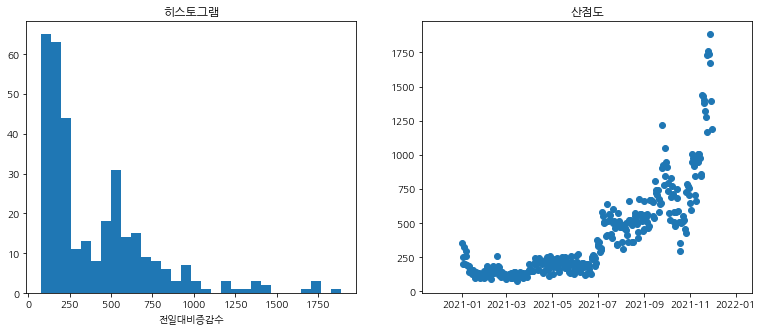

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].hist(ts_head['전일대비증감수'], bins=30)
ax[0].set_xlabel('전일대비증감수')
ax[0].set_title('히스토그램')

ax[1].scatter(ts_head.index, ts_head['전일대비증감수'])
ax[1].set_title('산점도')

plt.show()

In [48]:
display(ts_head.describe().T)

,count,mean,std,min,25%,50%,75%,max
전일대비증감수,334.0,405.152695,336.013188,79.0,152.0,252.5,556.0,1888.0


## 12-1-2. 시계열에 특화된 EDA

### 정상성 확인
전통적인 시계열 모델은 정상 시계열 데이터를 전제로 함. 정상성을 가지는 시계열은 시간이 지나더라도 평균과 분산이 일정하고  
추세나 계절성을 가지지 않음
- 정상성: 시간이 지나더라도 평균과 분산이 일정

- 정상성 확인방법
  - ADF: H0: 단위근이 있다.(정상성 만족안함) / **H1: 단위근이 없다.(정상성 만족)**
  - KPSS: H0: **정상성 만족** / H1: 정상성 만족안함
  
정상 데이터의 ACF 그래프는 시차가 증가할수록 0으로 빠르게 수렴하며, 비정상성 데이터는 느리게 감소

**<< 정상화 방법 >>**
- 평균이 일정하지 않을 경우: 데이터 차분
- 분산이 변화하는 경우: 로그변환(0이하 사용불가), 제곱근 변환, BOX-COX(0 이하 사용불가), Yeo-Johnson 등

ADF: 통계량 0.762 / p-value 0.991
KPSS: 통계량 2.210 / p-value 0.010


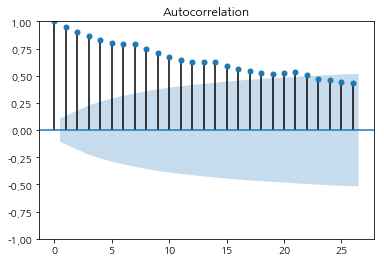

In [54]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf
f_list = [adfuller, kpss]
title = ['ADF', 'KPSS']

for f, t in zip(f_list, title):
    rs = f(ts_head)
    s, p = rs[0], rs[1]
    print(f"{t}: 통계량 {s:.3f} / p-value {p:.3f}")

plot_acf(ts_head)
plt.show()

ADF 검정결과는 귀무가설 기각할 수 없으므로, 정상성을 만족하지 않음  
KPSS 검정결과는 귀무가설을 기각하므로, 정상성을 만족하지 않음  
ACF 그래프는 lag 증가에 따라 값이 천천히 감소하므로 정상성을 만족하지 않음

### 자기상관 확인

서로 다른 시점의 데이터 간 선형적 상관관계를 의미하며, 자기상관함수(ACF), 편자기상관함수(PCAF) 그래프를 그리거나,  
융박스검정, 더빈왓슨 검정을 수행한다.  

- ACF: lag에 따른 관측치 사이의 관련성을 측정하는 함수, y값이 임계영역을 벗어나는 경우 자기상관이 있다고 판단
- PCAF: k이외의 다른 모든 시점 관측치의 영향력을 배제하고, yt와 yt-k의 관련성을 측정하는 함수  
  어느 시차의 데이터와 자기상관을 가지는지 확인 가능
- 융박스 검정: **H0: 자기상관이 없다.** / H1: 자기상관이 있다.
- 더빈왓슨 검정: **통계량이 2에 가까울수록 자기상관이 없고**, 0에 가까울수록 양의 상관관계, 4에 가까울수록 음의 관계

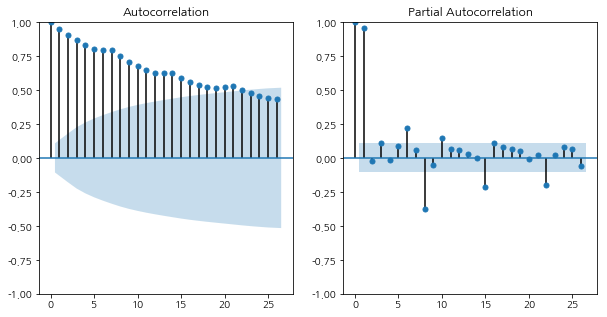

0 시차: 자기상관계수: 1.000, 신뢰구간: 1.000 ~ 1.000
1 시차: 자기상관계수: 0.954, 신뢰구간: 0.846 ~ 1.061
2 시차: 자기상관계수: 0.907, 신뢰구간: 0.727 ~ 1.087
3 시차: 자기상관계수: 0.873, 신뢰구간: 0.646 ~ 1.100


In [57]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
plot_acf(ts_head, ax=ax[0])
plot_pacf(ts_head, ax=ax[1])
plt.show()

# 시차별 자기상관계수 및 자기상관계수가 0이라는 95% 신뢰구간
acs, confs = acf(ts_head, fft=False, nlags=3, alpha=0.05, adjusted=True)
for lag, ac, conf, in zip(range(4), acs, confs):
    print(f"{lag} 시차: 자기상관계수: {ac:.3f}, 신뢰구간: {conf[0]:.3f} ~ {conf[1]:.3f}")


In [59]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson

rs = acorr_ljungbox(ts_head, return_df=True, auto_lag=True).head(3)
display(rs)

rs2 = durbin_watson(ts_head)
print(f"더빈왓슨: {rs2}")

,lb_stat,lb_pvalue
1,304.691106,3.131578e-68
2,579.605498,1.381228e-126
3,833.394832,2.474556e-180


더빈왓슨: [0.03337102]


융박스 검정의 p-value를 확인하면 모두 귀무가설을 기각하므로 자기상관이 있으며,   
더빈왓슨 검정의 통계량이 0.033으로 0에 가까우므로 양의 상관관계가 있다고 본다.

### 시계열 분해

추세, 계절성, 순환, 불규칙 변동으로 분해한다. 분해방법으로는 이동평균법, 지수평활법, STL 분해가 있다.  
- 이동평균법: 일정기간 이동평균을 계산하여 계절변동과 불규칙 변동을 제거하여 추세변동과 순환변동만 가진 시계열로 분해 가능
- 지수평활법: 불규칙 변동 제거 가능, 모든 시계열 자료를 사용하여 평균을 구하며 시간의 흐름에 따라 최근 시계열에 가중치를 더 부여
- STL 분해: 계절, 추세, 잔차 분해 가능

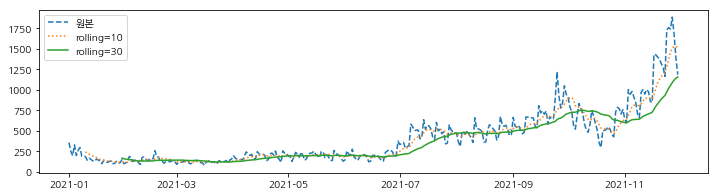

In [60]:
#이동평균법: 계절변동과 불규칙변동 제거
fig, ax = plt.subplots(1, 1, figsize=(12, 3))

title = ['원본', 'rolling=10', 'rolling=30']
rw10 = ts_head.rolling(window=10).mean().dropna()
rw30 = ts_head.rolling(window=30).mean().dropna()
dt_list = [ts_head, rw10, rw30]
ls_list = ['--', 'dotted', 'solid']

for t, d, l in zip(title, dt_list, ls_list):
    ax.plot(d, label=t, ls=l)
plt.legend()
plt.show()

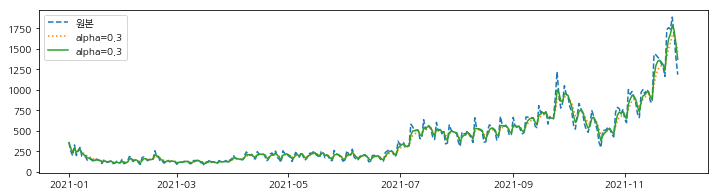

In [62]:
#지수평활법: 불규칙변동 제거
fig, ax = plt.subplots(1, 1, figsize=(12, 3))

title = ['원본', 'alpha=0.3', 'alpha=0.3']
e03 = ts_head.ewm(alpha=0.3).mean()
e05 = ts_head.ewm(alpha=0.5).mean()
dt_list = [ts_head, e03, e05]
ls_list = ['--', 'dotted', 'solid']

for t, d, l in zip(title, dt_list, ls_list):
    ax.plot(d, label=t, ls=l)
plt.legend()
plt.show()

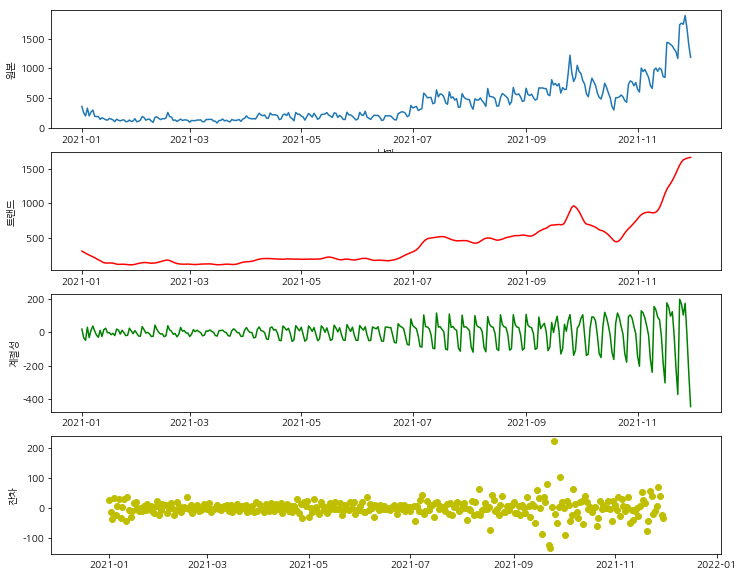

In [69]:
#STL 분해
from statsmodels.tsa.seasonal import STL

stl = STL(ts_head, seasonal=7, trend=9).fit() #주별 시즌
resid = stl.resid #잔차
seasonal = stl.seasonal #계절요소
trend = stl.trend #트랜드

title = ['원본', '트랜드', '계절성', '잔차']
dt_list = [ts_head, trend, seasonal, resid]
c_list = ['g', 'r', 'g', 'y']

fig, ax = plt.subplots(4, 1, figsize=(12, 10))

for t, d, ax, c in zip(title, dt_list, ax, c_list):
    ax.set_ylabel(t)
    if t != '잔차':
        sns.lineplot(data=d, ax=ax, color=c, legend=False)
    else:
        ax.scatter(x=d.index, y=d, color=c)
plt.show()

# 시계열 데이터 전처리
## 시계열 데이터 다루기

In [71]:
import datetime as dt
import time

ts = pd.read_csv('https://raw.githubusercontent.com/algoboni/pythoncodebook1-1/main/12_covid19.csv')

ts['날짜'] = pd.to_datetime(ts['날짜'], format='%Y-%m-%d')

In [72]:
# 날짜 데이터로 타입 변경하기 - (2) string - datetime
string = "2018-09-13 22:39:04"
print("string: ", type(string))
# string에서 나타내는 년월일 정보와 대응하도록 format을 적어줘야 해당 날짜로 인식 가능
datetime = dt.datetime.strptime(string, '%Y-%m-%d %H:%M:%S')
print("string to datetime: ", type(datetime))
string2 = datetime.strftime('%Y-%m-%d %H:%M:%S') 
print("datetime to string: ", type(string2))

string:  <class 'str'>
string to datetime:  <class 'datetime.datetime'>
datetime to string:  <class 'str'>


In [73]:
# 날짜 데이터로 타입 변경하기 - (3) timestamp - datetime
timestamp = 2551780740 #timestamp
datetime = dt.datetime.fromtimestamp(timestamp) # 로컬 기준
utcdatetime = dt.datetime.utcfromtimestamp(timestamp) # UTC 기준
timestamp2 = time.mktime(datetime.timetuple())
print(f"timestamp to local datetime (utc datetime): {datetime} ({utcdatetime})")
print("datetime to timestamp: ", timestamp2)

timestamp to local datetime (utc datetime): 2050-11-11 20:59:00 (2050-11-11 11:59:00)
datetime to timestamp:  2551780740.0


In [74]:
# 날짜 데이터 생성하기 - (1) dt.datetime
date1 = dt.datetime(2023, 3, 20, 16, 0, 0) 
#year, month, day, hour, minute, second, ...
date2 = dt.datetime.now()
date_only = dt.date(2019,1,1)
time_only = dt.time(10, 0, 5)
print("직접 지정해서 만든 날짜 데이터: ", date1)
print("현재 시간을 반환하는 날짜 데이터: ", date2)
print("date_only: ", date_only)
print('time_only: ', time_only)

직접 지정해서 만든 날짜 데이터:  2023-03-20 16:00:00
현재 시간을 반환하는 날짜 데이터:  2025-08-02 21:48:36.535264
date_only:  2019-01-01
time_only:  10:00:05


In [75]:
# 날짜 데이터 생성하기 - (2) pd.date_range, pd.period_range
## 시작날짜, 종료날짜, 날짜 개수(periods), 날짜의 간격 단위(freq)를 입력
## freq={'A(년)', 'M(월)', 'D(일))', 'T(분)'='min(분)' 'S(초)', 'Q(분기)', 'W(주)'}
date_list1 = pd.date_range('2016-01-01', periods=3, freq='D')
date_list2 = pd.date_range('2016-01-01', periods=4, freq='W')
date_list3 = pd.date_range('2016-01-01', '2016-01-02', freq='30T') #시간은 '60T'
print('일 단위 날짜들 3개:\n', date_list1, "\n")
print('주 단위 날짜들 4개:\n', date_list2, "\n")
print('시작-종료날짜 사이 30분 단위 날짜들:\n', date_list3[:2]) #앞의 2개만 print

일 단위 날짜들 3개:
 DatetimeIndex(['2016-01-01', '2016-01-02', '2016-01-03'], dtype='datetime64[ns]', freq='D') 

주 단위 날짜들 4개:
 DatetimeIndex(['2016-01-03', '2016-01-10', '2016-01-17', '2016-01-24'], dtype='datetime64[ns]', freq='W-SUN') 

시작-종료날짜 사이 30분 단위 날짜들:
 DatetimeIndex(['2016-01-01 00:00:00', '2016-01-01 00:30:00'], dtype='datetime64[ns]', freq='30T')


In [76]:
date_list4 = pd.period_range('2012-01-01', freq='A', periods=2)
date_list5 = pd.period_range('2012-01-01', freq='Q', periods=3)
print('년 단위 날짜들 2개:\n', date_list4, "\n")
print('분기 단위 날짜들 3개:\n', date_list5)

년 단위 날짜들 2개:
 PeriodIndex(['2012', '2013'], dtype='period[A-DEC]', freq='A-DEC') 

분기 단위 날짜들 3개:
 PeriodIndex(['2012Q1', '2012Q2', '2012Q3'], dtype='period[Q-DEC]', freq='Q-DEC')


In [78]:
# 날짜 데이터의 형태, 값 변경하기
date3 = dt.datetime(2023, 3, 20, 0, 1, 10)
date3_c1 = date3.strftime("%Y-%m-%d") #네자리 년도, 월, 일
print("형태 변경 전: ", date3)
print("형태 변경 후 1: ", date3_c1) 

형태 변경 전:  2023-03-20 00:01:10
형태 변경 후 1:  2023-03-20


In [79]:
date4 = date3.replace(year = 2022, minute=2)
# year, month, day, hour, minute, second, ...
print("값 변경 전: ", date3)
print("값 변경 후: ", date4)

값 변경 전:  2023-03-20 00:01:10
값 변경 후:  2022-03-20 00:02:10


In [80]:
date_only = dt.date(2019,1,1)
time_only = dt.time(10, 0, 5)
datetime = dt.datetime.combine(date_only, time_only)
print("값 병합 전: ", date_only, time_only)
print("값 병합 후: ", datetime)

값 병합 전:  2019-01-01 10:00:05
값 병합 후:  2019-01-01 10:00:05


In [81]:
# 날짜 데이터 간 연산하기
## weeks, days, hours, minutes, ...
weeks1 = dt.timedelta(weeks = 1)
today = dt.date(2023,2,10)
print("오늘: ", today)
print("오늘로부터 1주 전: ", today - weeks1)
print("오늘로부터 1주 후: ", today + weeks1)

오늘:  2023-02-10
오늘로부터 1주 전:  2023-02-03
오늘로부터 1주 후:  2023-02-17


In [82]:
# 년, 월, 일, 요일명, 요일인덱스 추출하기
print("\n 년, 월, 일, 요일명, 요일인덱스 추출하기: \n")
ts['날짜'] = ts['날짜'].astype('datetime64') #날짜의 데이터 타입 변경
ts['년'] = ts['날짜'].dt.year #날짜 feature에서 년 정보를 추출
ts['월'] = ts['날짜'].dt.month
ts['일'] = ts['날짜'].dt.day
ts['요일1'] = ts['날짜'].dt.weekday #0~6(월요일~일요일)
ts['요일2'] = ts['날짜'].dt.day_name() #영어 요일명
print(ts.filter(['날짜', '년', '월', '일', '요일1', '요일2']).head(5))


 년, 월, 일, 요일명, 요일인덱스 추출하기: 

          날짜     년  월  일  요일1       요일2
0 2021-01-01  2021  1  1    4    Friday
1 2021-01-02  2021  1  2    5  Saturday
2 2021-01-03  2021  1  3    6    Sunday
3 2021-01-04  2021  1  4    0    Monday
4 2021-01-05  2021  1  5    1   Tuesday


### 시계열 빈도변경(업,  다운샘플링)

In [84]:
ts = pd.read_csv('https://raw.githubusercontent.com/algoboni/pythoncodebook1-1/main/12_covid19.csv')
# 날짜 column의 데이터 타입을 변경하고 인덱스로 셋팅한다.
ts['날짜'] = ts['날짜'].astype('datetime64')
ts = ts.set_index('날짜')

In [85]:
# rule = 'A(년)', 'M(월)', 'D(일))', 'T(분)'='min(분)' 'S(초)', 'Q(분기)', 'W(주)'
# aggregating = .asfreq(), .sum(), .mean()
print("[freq='Q', asfreq]") # 해당 기간의 대표 날짜의 데이터를 반환
print(ts.resample(rule='Q').asfreq())

[freq='Q', asfreq]
            누적확진자수  전일대비증감수
날짜                         
2021-03-31   32029      158
2021-06-30   49986      375
2021-09-30  100492      945
2021-12-31  225235     1670


In [86]:
print("[freq='Q', sum] ") # 해당 기간의 데이터 합을 반환
print(ts.resample(rule='Q').sum())

[freq='Q', sum] 
              누적확진자수  전일대비증감수
날짜                           
2021-03-31   2357075    13034
2021-06-30   3726692    17957
2021-09-30   6672971    50508
2021-12-31  13440595   124799


In [87]:
print("[freq='Q', mean] ") # 해당 기간의 데이터 평균을 반환
print(ts.resample(rule='Q').mean())

[freq='Q', mean] 
                   누적확진자수      전일대비증감수
날짜                                    
2021-03-31   26189.722222   144.822222
2021-06-30   40952.659341   197.329670
2021-09-30   72532.293478   549.000000
2021-12-31  146093.423913  1356.510870


### 결측치 처리

- forward fill: 이전 값으로 누락 값 채우기   
- backward fill: 이후 값으로 채우기  
  데이터를 사용하여 미래를 예측하지 않거나 특정분야의 지식에 기반하여 미래보다 과거를 채우는 게 의미있을 때만 사용
- 이동평균: 과거의 값으로 미래의 값 예측관점 포워드와 유사(산술평균과 지수가중이동평균이 있음)
- 보간: 인접 데이터 사용 누락 데이터 추정 및 보간

In [89]:
ts = pd.read_csv('https://raw.githubusercontent.com/algoboni/pythoncodebook1-1/main/12_covid19.csv').filter(['날짜', '전일대비증감수'])
ts['날짜'] = ts['날짜'].astype('datetime64')
ts = ts.set_index('날짜')
print("결측치 확인: ", ts.isna().sum())

결측치 확인:  전일대비증감수    0
dtype: int64


In [107]:
import numpy as np

ts2 = ts.copy()
rn = np.random.randint(0, len(ts)-1, 50)
ts2.iloc[rn] = np.nan

ts2.isna().sum()

전일대비증감수    47
dtype: int64

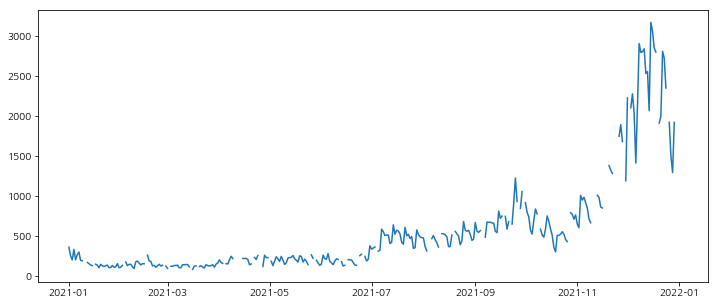

In [110]:
plt.figure(figsize=(12, 5))
plt.plot(ts2)
plt.show()

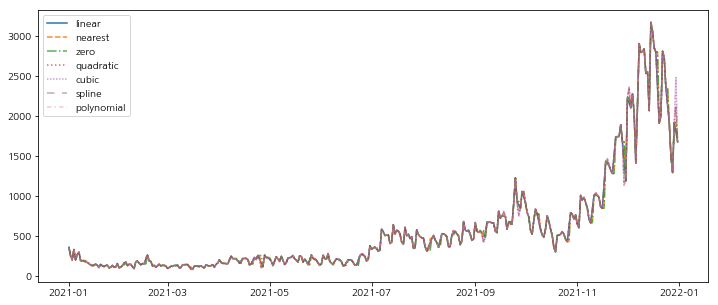

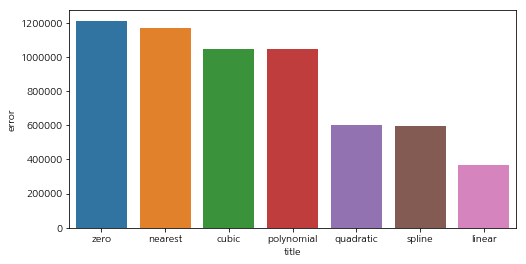

In [120]:
linear = ts2.interpolate(method='linear')
nearst = ts2.interpolate(method='nearest')
zero = ts2.interpolate(method='zero')
quad = ts2.interpolate(method='quadratic') #poly=2
cubic = ts2.interpolate(method='cubic')
spline = ts2.interpolate(method='spline', order=2)
poly = ts2.interpolate(method='polynomial', order=3)

titles = ['linear', 'nearest', 'zero', 'quadratic', 'cubic', 'spline', 'polynomial']
data_list = [linear, nearst, zero, quad, cubic, spline, poly]
linestyles = ['-', '--', '-.', ':', (0, (1, 1)), (0, (5, 5)), (0, (3, 2, 1, 2))]
ap = np.arange(1, 0.3, -0.1)

sqrd_error = []

fig, ax = plt.subplots(1, 1, figsize = (12, 5))
for t, d, l, a in zip(titles, data_list, linestyles, ap):
    sqrd_e = sum((ts - d)['전일대비증감수']**2)
    sqrd_error.append(sqrd_e)
    ax.plot(d, label=t, ls=l, alpha=a)
plt.legend()
plt.show()
rs = pd.DataFrame({'title':titles, 'error':sqrd_error}).sort_values(by='error', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='title', y='error', data=rs, label='squared error')
plt.show()

### 차분과 변환

In [121]:
ts = pd.read_csv('https://raw.githubusercontent.com/algoboni/pythoncodebook1-1/main/12_covid19.csv').filter(['날짜', '전일대비증감수'])
ts['날짜'] = ts['날짜'].astype('datetime64') #날짜 데이터로 설정
ts = ts.set_index('날짜') #인덱스를 날짜로 셋팅
ts_head = ts.head(334) # 2021년 1~11월 데이터
ts_tail = ts.tail(31) # 2022년 12월 데이터

original: ADF p-value 0.991, KPSS p-value 0.010
diff(1): ADF p-value 0.004, KPSS p-value 0.100
diff(2): ADF p-value 0.005, KPSS p-value 0.100


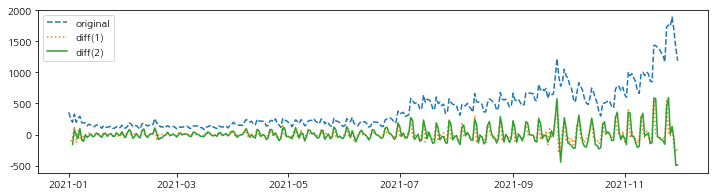

In [122]:
from statsmodels.tsa.stattools import adfuller, kpss
fig, ax = plt.subplots(1,1, figsize=(12,3))

titles = ['original', 'diff(1)', 'diff(2)']
diff1 = ts_head.diff(periods=1).dropna()
diff2 = ts_head.diff(periods=2).dropna()
data_list = [ts_head, diff1, diff2]
ls_list = ['dashed', 'dotted', 'solid']

for title, data, ls in zip(titles, data_list, ls_list):
    ax.plot(data, label=title, linestyle=ls)
    ap = adfuller(data)[1]
    kp = kpss(data)[1]
    print(f"{title}: ADF p-value {ap:.3f}, KPSS p-value {kp:.3f}")
plt.legend()
plt.show()
## 1번의 차분으로 정상시계열이 되었다.

original: ADF p-value 0.991, KPSS p-value 0.010
log: ADF p-value 0.001, KPSS p-value 0.100
box-cox: ADF p-value 0.000, KPSS p-value 0.100


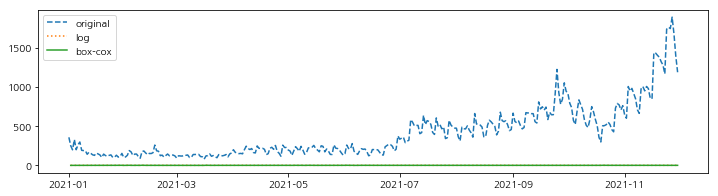

In [125]:
# 변환과 차분 전후 비교
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.preprocessing import PowerTransformer
# 로그변환
log = np.log(ts_head)
# 박스콕스 변환
pt = PowerTransformer(method='box-cox')
rescaled = pt.fit_transform(ts_head)
boxcox = pd.DataFrame(rescaled, index=ts_head.index, columns=ts_head.columns)
# 차분 1회
log = log.diff(1).dropna()
boxcox = boxcox.diff(1).dropna()

# 시각화
titles = ['original', 'log', 'box-cox']
data_list = [ts_head, log, boxcox]
ls_list = ['dashed', 'dotted', 'solid']
fig, ax = plt.subplots(1,1, figsize=(12,3))
for title, data, ls in zip(titles, data_list, ls_list):
    ax.plot(data, label=title, linestyle=ls)
    ap = adfuller(data)[1]
    kp = kpss(data)[1]
    print(f"{title}: ADF p-value {ap:.3f}, KPSS p-value {kp:.3f}")
plt.legend()
plt.show()

# 12-3. 시계열 모델링 및 평가


| 모델명     | 주요 특징                                                                                                 | 적용 상황/사용 예                                                                          |
|:----------|:------------------------------------------------------------------------------------------------------|:----------------------------------------------------------------------------------------|
| **AR (자기회귀, AutoRegressive)**            | - 과거 데이터(자신의 시차 값) 선형 조합으로 현재값 예측<br>- "자기자신에 대한 회귀" 모델- AR(p): p 시차까지 사용           | - 주식/금리 등 과거 패턴이 미래에도 반복될 때<br>- 단기 예측, 정상성 시계열                 |
| **MA (이동평균, Moving Average)**            | - 과거 오차항(잡음, 잔차)의 선형 결합으로 현재값 예측<br>- MA(q): q 시차 전 오차까지 결합식       | - 잔차(예측오차) 패턴이 반복되는 데이터<br>- 금융 시계열, 백색잡음 필터링                   |
| **ARMA (자기회귀+이동평균 혼합)**            | - AR과 MA 특성을 결합한 모델<br>- 정상성 시계열에 적합- ARMA(p, q)                        | - 정상성(log, 생산량 등 변화폭이 일정한 시계열)<br>- 경제/공업 생산지수 등                  |
| **ARIMA (차분 후 ARMA, 비정상성 처리)**     | - ARMA 기반에 차분(differencing, I) 연산 추가<br>- 트렌드/비정상 데이터 분석에 적합- ARIMA(p,d,q) | - 매출, 기상(온도 등) 등 추세성·비정상성 강한 시계열<br>- 계절성, 예측, 경제/마케팅 데이터         |

- **AR**: 자기 자신(lagged value) 반복성이 중요한 데이터에,
- **MA**: 오차 내 잡음 패턴이 구조적으로 남아모델에 적합,
- **ARMA**: 정상성 시계열(추세/계절성 없는)일 때,
- **ARIMA**: 추세나 비정상성이 있는 데이터를 일단 차분(d)한 후 모델.

**예시:**  
- *주가·금리 예측(AR, ARIMA)*  
- *날씨·온도 데이터(ARIMA)*  
- *공장 생산 지표(ARMA)*  
- *노이즈 제거(간단 MA)*

추가로 계절성이 강한 경우엔 SARIMA, 다변량 시계열은 VAR, LSTM 등도 활용 가능하며,  
모델 선정 시 데이터가 **정상성 시계열인지** 먼저 판단하는 것이 중요

| 모형    | ACF 패턴                         | PACF 패턴                        |
|:--------|:---------------------------------|:---------------------------------|
| AR(p)   | 점차적으로 감소(tailing off)      | lag p에서 처음으로 끊김            |
| MA(q)   | lag q에서 처음으로 끊김            | 점차적으로 감소(tailing off)      |
| ARMA    | 점차적으로 감소(tailing off)      | 점차적으로 감소(tailing off)      |

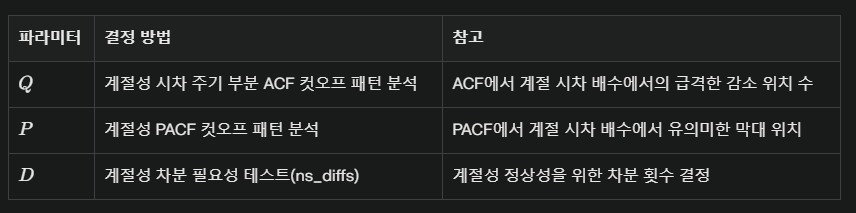

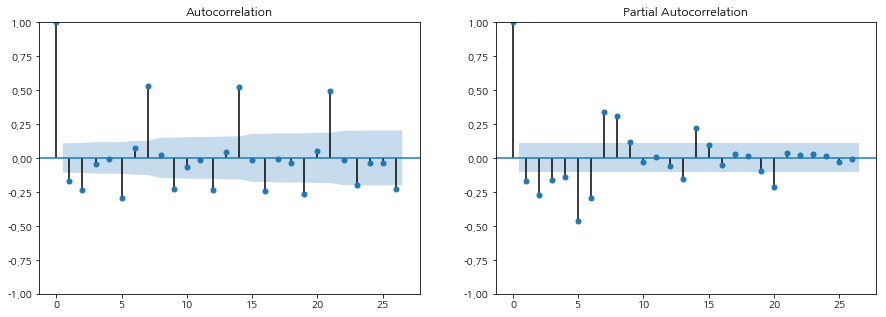

In [127]:
# 박스-젠킨스 방법
## boxcox 변환 및 차분을 통해 정상화한 시계열 데이터 'boxcox'로 적절한 차수를 찾기
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, ax = plt.subplots(1,2, figsize=(15,5))
plot_acf(boxcox, ax=ax[0])
plot_pacf(boxcox, ax=ax[1])
plt.show()
## 차수는 plot 상의 절단점을 참고하여 p=9, q=2로 정하고 모델을 적합하기로 한다. 계절성이 있는 것으로 보인다.

# 모델의 비계절성 부분
p = 9 #AR 차수
d = 1 #차분 횟수
q = 2 #MA 차수

# 모델의 계절성 부분 (계절성이 없으면 생략 가능)
P = 0
D = 0
Q = 1 #ACF lag7에서 뾰족한 막대를 가지고, PACF는 지수적으로 감소
s = 7 #ACF lag7에서 뾰족한 막대를 가짐, 계절성 단위 (seasonal period)

- 계절성 차수 결정
  - ACF: lag 7, 14, 21 등 7 단위로 튀는 값이 존재, s=7, 계절성 차분 미수행으로 D=0, Q=1   
    그래프의 배수 lag에서 급격하게 감소하는 수가 없으며, PACF가 지수적으로 감소하므로
    
- 비계절성 차수
  - p: PACF lag10에서 처음으로 신뢰구간에 속하므로 9
  - q: ACF lag3에서 처음으로 신뢰구간에 속하므로 2
  - d: 차분을 1번 수행했으므로 1  

In [128]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
# ARIMA에서 seasonal_order를 입력하면 SARIMAX와 동일한 결과를 얻음
model = ARIMA(ts_head, order=(p, d, q), seasonal_order=(P, D, Q, s)) #원본 데이터 입력
fitted = model.fit()
resid = fitted.resid

# pred1과 pred2는 동일한 값임
pred1 = fitted.forecast(31) #이후 31개 날짜의 값을 예측
pred2 = fitted.predict(start=ts_tail.index[0], end=ts_tail.index[-1]) #시작/종료날짜로 예측
# 잔차의 정규성 확인: Jarque-Bera 검정을 통해 귀무가설을 채택하면, 정규성을 갖는다.
# 잔차의 자기상관 확인: Ljung-Box 검정을 통해 귀무가설을 채택하면, 자기상관이 없다.

print(fitted.summary())

                                     SARIMAX Results                                     
Dep. Variable:                           전일대비증감수   No. Observations:                  334
Model:             ARIMA(9, 1, 2)x(0, 0, [1], 7)   Log Likelihood               -1854.019
Date:                           Sat, 02 Aug 2025   AIC                           3734.037
Time:                                   22:47:06   BIC                           3783.543
Sample:                               01-01-2021   HQIC                          3753.778
                                    - 11-30-2021                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0282      0.999     -0.028      0.977      -1.986       1.929
ar.L2         -0.1720      0.495     -0.347

SARMA(9, 1, 2)x(0, 0, 1, 7) 모델 학습 결과이다.

- Log Likelihood 값은 수치가 높을수록 모형 적합도가 높아짐 -1854.019(낮음)
- AIC(낮을수록 좋음):  3734.
- BIC(낮을수록 좋음, 모델 단순성까지 고려): 3783

- 모수추정결과: 유의확률 5% 하에서 통계적으로 유의 여부(대부분 유의하지 않음)
    - ar.L1: AR(1) 계수
    - ar.L2: AR(2) 계수
    - ma.L1: MA(1) 계수 
    - sigma2: 오차의 분산(낮을수록 예측이 정밀함)
    - 잔차진단: 독립성, 등분산성 만족(정규성 불만족)

- Ljung-Box: p-value 0.96 로 잔차에 자기상관 없음  
- Jarque-Bera (JB): p-value 0.00로 잔차가 정규분포를 따르지 않음  
- Heteroskedasticity (H): p-value 0.00로 잔차가 이분산임  

MAE: 1391.254
RMSE: 1434.516


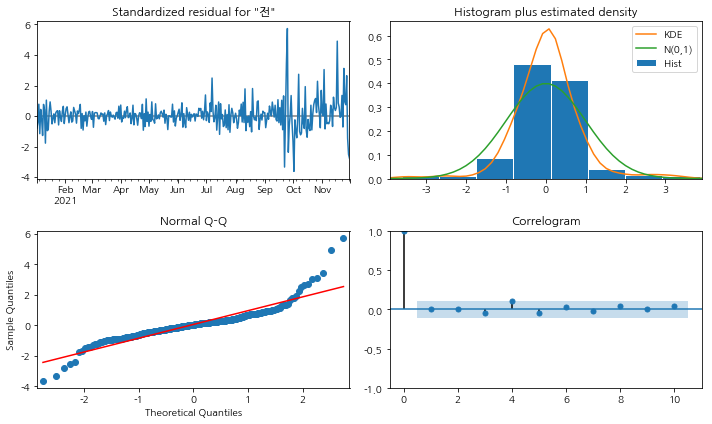

In [132]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

forecast = fitted.get_forecast(steps=len(ts_head))
f_mean = forecast.predicted_mean
MAE = mean_absolute_error(ts_head, f_mean)
rmse = np.sqrt(mean_squared_error(ts_head, f_mean))
print(f"MAE: {MAE:.3f}")
print(f"RMSE: {rmse:.3f}")
fitted.plot_diagnostics(figsize=(10, 6)) #잔차 그래프
plt.tight_layout()
plt.show()

잔차 그래프를 통해 이분산, 정규성 따르지 않음을 확인할 수 있음

### 자동 차수 선택방법과 arima

In [134]:
from pmdarima import auto_arima
auto_arima(ts_head, start_p=1, start_q=1, max_p=5, max_q=5, start_P=0, 
           start_Q=0, max_P=5, max_Q=5, m=7, seasonal=True, trace=False, error_action='warn', suppress_warnings=True)

ARIMA(order=(3, 1, 0), scoring_args={}, seasonal_order=(1, 0, 1, 7),
      suppress_warnings=True, with_intercept=False)

In [138]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(ts_head, order=(3, 1, 0), seasonal_order=(1, 0, 1, 7))
fitted = model.fit()
resid = fitted.resid
pred3 = fitted.forecast(31) # 이후 31개 날짜의 값을 예측
pred4 = fitted.predict(start=ts_tail.index[0], end=ts_tail.index[-1]) # 날짜 데이터로 예측
# 잔차의 정규성 확인: Jarque-Bera 검정을 통해 귀무가설을 채택하면, 정규성을 갖는다.
# 잔차의 자기상관 확인: Ljung-Box 검정을 통해 귀무가설을 채택하면, 자기상관이 없다.

print(fitted.summary())

                                     SARIMAX Results                                     
Dep. Variable:                           전일대비증감수   No. Observations:                  334
Model:             ARIMA(3, 1, 0)x(1, 0, [1], 7)   Log Likelihood               -1852.753
Date:                           Sat, 02 Aug 2025   AIC                           3717.507
Time:                                   22:59:40   BIC                           3740.355
Sample:                               01-01-2021   HQIC                          3726.618
                                    - 11-30-2021                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2260      0.036     -6.293      0.000      -0.296      -0.156
ar.L2         -0.1731      0.039     -4.395


| 지표명                      | 정의 및 설명                                                                                  | 해석 기준 및 특징                                                                                                                    |
|----------------------------|--------------------------------------------------------------------------------------------|----------------------------------------------------------------------------------------------------------------------------------|
| **Ljung-Box (Q) 통계량**     | 시계열 잔차의 자기상관 검정 통계량으로, 시계열이 독립인지 점검                             | - **작을수록 잔차 간 자기상관 적음 (≒ 백색잡음)**<br>**-귀무가설일 시 잔차의 독립성** |
| **Prob(Q) (p-value)**        | Ljung-Box Q 테스트의 p-value, 잔차 자기상관 없다는 귀무가설에 대한 신뢰도                   | - **귀무:** 잔차의 자기상관 통계적으로 유의하지 않음 (잔차 독립)<br>- **대립:** 잔차 자기상관 존재 의심                      |
| **Jarque-Bera (JB) 통계량** | 잔차(오차)의 정규성 검정 통계량 (왜도와 첨도를 이용)                                     | - 값이 클수록 정규성에서 더 멀어짐                                                                                                  |
| **Prob(JB)**                 | JB 통계량에 대한 p-value, 잔차 정규성 귀무가설(정규 분포 따름)에 대한 신뢰도               | - **귀무:** 정규성 기각 안됨 (잔차 정규 분포 가능)<br>- **대립:** 정규성 기각 (잔차 비정규)                                  |
| **Heteroskedasticity (H)**   | 잔차의 이분산성 존재 여부 통계량, 잔차 분산이 일정한지 여부 평가                          | - 1에 가까울수록 등분산성 유지<br>- 1보다 크면 이분산성(heteroskedasticity) 의심                                                          |
| **Prob(H) (two-sided)**      | 이분산성 검정 p-value                                                                      | - **귀무:** 등분산성 유지<br>- **대립:** 이분산성 존재 가능성 높음                                                        |
| **Skew (왜도)**              | 분포의 비대칭 정도를 나타냄, 0이면 대칭                                                 | - **0에 가까우면 대칭형 분포**<br>- 양수면 오른쪽 긴 꼬리(positive skew)- 음수면 왼쪽 긴 꼬리(negative skew)                         |
| **Kurtosis (첨도)**          | 분포의 꼬리 두꺼움 정도, 정상분포 = 3                                                   | - **3보다 크면 뾰족한 분포(leptokurtic)**<br>- **3보다 작으면 평평한 분포(platykurtic)**                                               |

### 해석 예시 (위 지표 기반)

| 지표                        | 값    | 해석 (예)                                                    |
|----------------------------|-------|------------------------------------------------------------|
| Ljung-Box (Q)              | 0.01  | 매우 낮은 값, 잔차 자기상관 없어 보임                        |
| Prob(Q)                    | 0.93  | 0.05 이상 → 잔차 자기상관 통계적으로 유의하지 않음 → 잔차 독립    |
| Jarque-Bera (JB)           | 918.22| 큼 → 정규성 위배 가능성 높음                                 |
| Prob(JB)                   | 0.00  | 0.05 이하 → 잔차 정규성 기각 (비정규성 존재)                  |
| Heteroskedasticity (H)     | 8.14  | 1보다 크고 상당히 큼 → 이분산성 강함                            |
| Prob(H)                    | 0.00  | 0.05 이하 → 이분산성 존재 통계적 근거 강함                      |
| Skew                       | 0.93  | 양의 왜도 → 분포 오른쪽 꼬리 길고 비대칭                        |
| Kurtosis                   | 10.92 | 3보다 큼 → 분포에 뾰족하고 극단값 많음을 의미                    |


MAE: 3821.595
RMSE: 3979.263


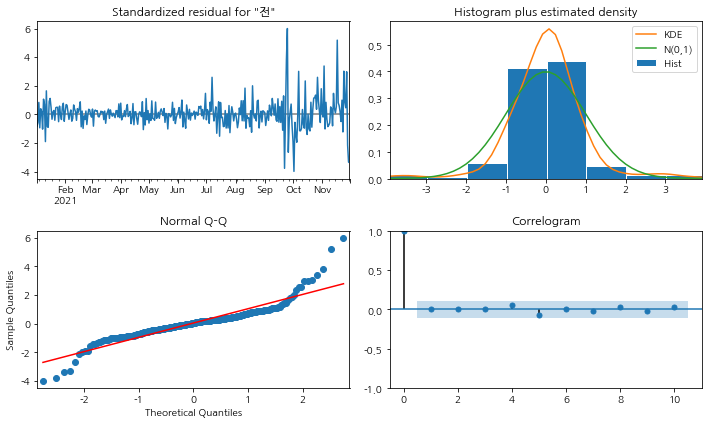

In [139]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

forecast = fitted.get_forecast(steps=len(ts_head))
f_mean = forecast.predicted_mean
MAE = mean_absolute_error(ts_head, f_mean)
rmse = np.sqrt(mean_squared_error(ts_head, f_mean))
print(f"MAE: {MAE:.3f}")
print(f"RMSE: {rmse:.3f}")
fitted.plot_diagnostics(figsize=(10, 6)) #잔차 그래프
plt.tight_layout()
plt.show()

In [140]:
# 자동 차수 선택2 - 반복문 사용
import itertools
p = range(0,4)
d = range(1,2)
q = range(0,3)
Q = D = P = range(0,2)
m = [4, 7, 12]
combis = list(itertools.product(p,d,q, P,D,Q,m))

dict_model ={}
for i, combi in enumerate(combis):
    try:
        no_seasonal = combi[:3]
        seasonal = combi[3:]
        model = ARIMA(ts_head, order=(no_seasonal), seasonal_order=(seasonal))
        fitted = model.fit()
        dict_model[combi]=[fitted.llf, fitted.aic]
        # llf(likelihood)는 높을 수록 좋음
        # AIC는 낮을 수록 좋음
    except:
        print("except: ", i, combi) # LU decomposition error 발생하는 경우 pass
        continue
        
result = pd.DataFrame.from_dict(dict_model, orient ="index", columns =["llf", "AIC"]).sort_values(by='AIC', ascending=True)
print(result)

                               llf          AIC
(1, 1, 0, 1, 0, 1, 7)     0.000000     8.000000
(3, 1, 2, 1, 0, 1, 7)   -80.879107   177.758213
(3, 1, 1, 0, 1, 1, 7) -1807.948928  3627.897856
(3, 1, 2, 0, 1, 1, 7) -1807.944495  3629.888991
(3, 1, 0, 0, 1, 1, 7) -1810.092109  3630.184218
...                            ...          ...
(3, 1, 0, 0, 1, 0, 4) -2067.112994  4142.225988
(2, 1, 0, 0, 1, 0, 4) -2086.585068  4179.170136
(0, 1, 1, 0, 1, 0, 4) -2088.194196  4180.388392
(1, 1, 0, 0, 1, 0, 4) -2088.409186  4180.818373
(0, 1, 0, 0, 1, 0, 4) -2089.657718  4181.315436

[288 rows x 2 columns]


In [144]:
result.sort_values(by='AIC')

,llf,AIC
"(1, 1, 0, 1, 0, 1, 7)",0.000000,8.000000
"(3, 1, 2, 1, 0, 1, 7)",-80.879107,177.758213
"(3, 1, 1, 0, 1, 1, 7)",-1807.948928,3627.897856
"(3, 1, 2, 0, 1, 1, 7)",-1807.944495,3629.888991
"(3, 1, 0, 0, 1, 1, 7)",-1810.092109,3630.184218
...,...,...
"(3, 1, 0, 0, 1, 0, 4)",-2067.112994,4142.225988
"(2, 1, 0, 0, 1, 0, 4)",-2086.585068,4179.170136
"(0, 1, 1, 0, 1, 0, 4)",-2088.194196,4180.388392
"(1, 1, 0, 0, 1, 0, 4)",-2088.409186,4180.818373


In [145]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(ts_head, order=(3, 1, 2), seasonal_order=(0, 1, 1, 7))
fitted = model.fit()
resid = fitted.resid
pred5 = fitted.forecast(31)
pred6 = fitted.predict(start=ts_tail.index[0], end=ts_tail.index[-1])
# 잔차의 정규성 확인: Jarque-Bera 검정을 통해 귀무가설을 채택하면, 정규성을 갖는다.
# 잔차의 자기상관 확인: Ljung-Box 검정을 통해 귀무가설을 채택하면, 자기상관이 없다.

print(fitted.summary())

                                     SARIMAX Results                                     
Dep. Variable:                           전일대비증감수   No. Observations:                  334
Model:             ARIMA(3, 1, 2)x(0, 1, [1], 7)   Log Likelihood               -1807.944
Date:                           Sat, 02 Aug 2025   AIC                           3629.889
Time:                                   23:08:57   BIC                           3656.397
Sample:                               01-01-2021   HQIC                          3640.467
                                    - 11-30-2021                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9405      0.218     -4.319      0.000      -1.367      -0.514
ar.L2         -0.2962      0.255     -1.164

MAE: 4859.680
RMSE: 5209.254


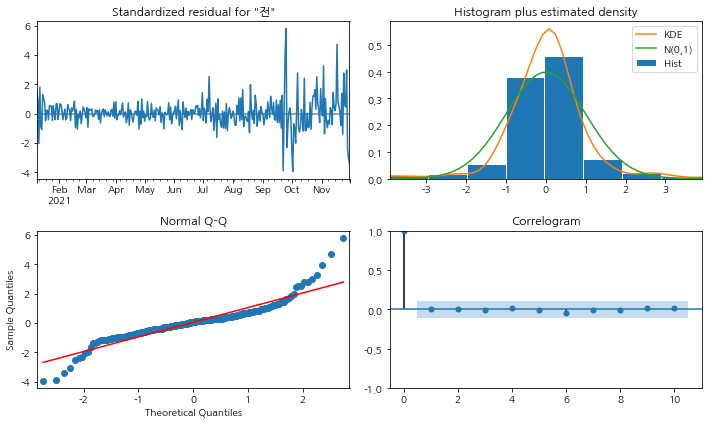

In [146]:
forecast = fitted.get_forecast(steps=len(ts_head))
f_mean = forecast.predicted_mean
MAE = mean_absolute_error(ts_head, f_mean)
rmse = np.sqrt(mean_squared_error(ts_head, f_mean))
print(f"MAE: {MAE:.3f}")
print(f"RMSE: {rmse:.3f}")
fitted.plot_diagnostics(figsize=(10, 6)) #잔차 그래프
plt.tight_layout()
plt.show()

In [147]:
from sklearn.metrics import r2_score
import numpy as np
def MAPE(y_true, y_pred):
    mape = np.mean(np.abs((y_true - y_pred)/y_true))*100
    return mape

titles = ["box-jenkins", "auto_arima", "for loop"]
ts_tail1d = ts_tail.values.ravel()
preds = [pred1.values, pred3.values, pred5.values]
for title, pred in zip(titles, preds):
    r2 = r2_score(ts_tail1d, pred)
    mape = MAPE(ts_tail1d, pred)
    print("{}:  R2 {:.3f}, MAPE {:.3f}".format(title, r2, mape))

box-jenkins:  R2 -1.519, MAPE 26.662
auto_arima:  R2 -0.740, MAPE 24.503
for loop:  R2 -0.660, MAPE 24.426


loop 모델이 그나마 나음

# 연습문제

1. 다음은 마이크로소프트 주식 가격 데이터이다. 데이터는 날짜와 주식종가로 구성되어 있다.  
   다음 데이터를 주 단위 평균가격으로 다운샘플링하고, 앞의 데이터 300개를 down_head, 뒤의 데이터 14개를 down_tail로 분할하시오.

In [251]:
ms = pd.read_csv('https://raw.githubusercontent.com/algoboni/pythoncodebook1-1/main/practice12_ms_stock.csv')
ms['Date'] = ms['Date'].astype('datetime64')
ms = ms.set_index('Date')
display(ms)

,Close
Date,
2015-04-01 16:00:00,40.72
2015-04-02 16:00:00,40.29
2015-04-06 16:00:00,41.55
2015-04-07 16:00:00,41.53
2015-04-08 16:00:00,41.42
...,...
2021-03-25 16:00:00,232.34
2021-03-26 16:00:00,236.48
2021-03-29 16:00:00,235.24


In [252]:
ms = ms.resample(rule='W').mean()
down_head = ms.head(300)
down_tail = ms.tail(14)

2. down_head 데이터로 탐색적 데이터분석을 진행하시오.

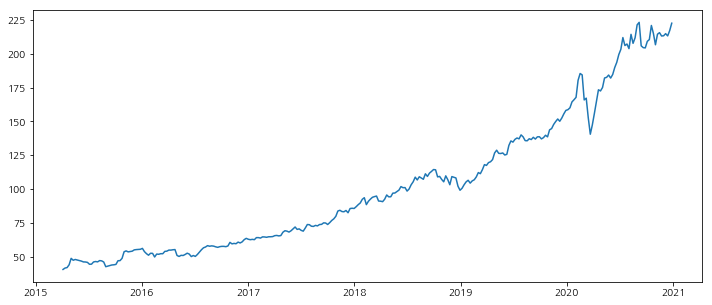

In [253]:
down_head.isna().sum()

plt.figure(figsize=(12, 5))
plt.plot(down_head)
plt.show()

ADF: 통계량 2.240 / p-value 0.999
KPSS: 통계량 2.593 / p-value 0.010


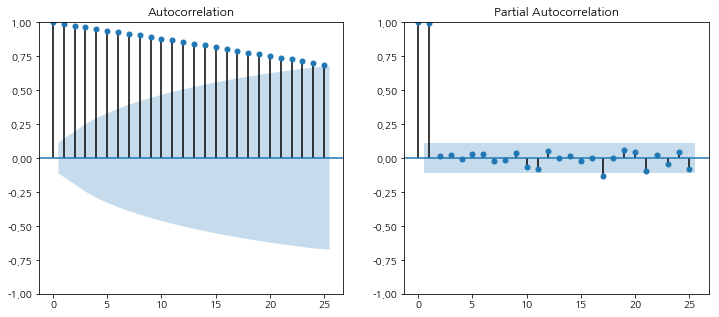

,lb_stat,lb_pvalue
1,294.753777,4.579097e-66
2,582.583051,3.116721e-127
3,863.943057,5.859132e-187


In [254]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
f_list = [adfuller, kpss]
title = ['ADF', 'KPSS']

def check(dt):
    for f, t in zip(f_list, title):
        rs = f(dt)
        s, p = rs[0], rs[1]
        print(f"{t}: 통계량 {s:.3f} / p-value {p:.3f}")

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    plot_acf(dt, ax=ax[0])
    plot_pacf(dt, ax=ax[1])
    plt.show()

    rs = acorr_ljungbox(dt, return_df=True, auto_lag=True).head(3)
    display(rs)
    
check(down_head)

- ADF 결과, 귀무가설을 기각할 수 없어 정상성이 없으며,   
- KPSS 결과, 귀무가설을 기각하여 정상성이 없다.  
- ACF 그래프 값이 천천히 감소하므로 비정상성이다.  

융박스 테스트 결과, 귀무가설을 기각하여 자기상관이 있는 것을 확인할 수 있다. 

따라서 차분 및 변환을 실시한다.

ADF: 통계량 -10.291 / p-value 0.000
KPSS: 통계량 0.343 / p-value 0.100


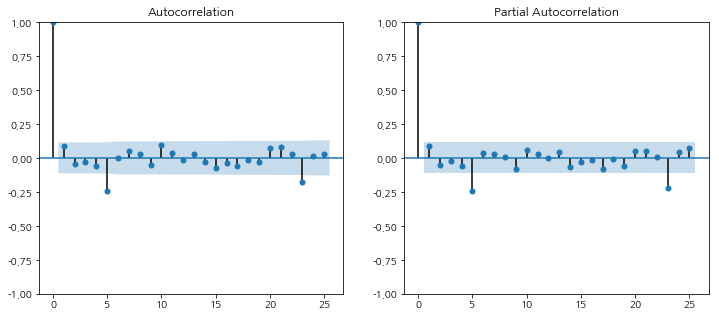

,lb_stat,lb_pvalue
1,2.302389,0.129175
2,2.874505,0.237580
3,3.202658,0.361422


In [259]:
from scipy.stats import boxcox

# # x : 양수 데이터 (음수/0은 변환 전 보정 필요)
box, lamb = boxcox(down_head['Close'])
down_head['boxcox'] = box #로그화한 값만을 사용

diff = down_head['Close'].diff(1).dropna()
check(diff)

ADF 결과, 귀무가설을 기각하여, 정상성이 있다.  
KPSS 결과, 귀무가설을 기각할 수 없어 정상성이 있다.  
ACF 그래프 값이 급격히 줄어들었으므로 정상성이 있다.  
융박스 테스트 결과, 귀무가설을 기각할 수 없어 정상성이 있다.  

3. down_head 데이터로 시계열 모델을 적합하시오.

차분을 1회 수행하였으므로 d = 1이며, ACF 그래프에서 눈에 띄는 lag 배수의 특정값이 없으므로 계절성 모델은 아니다.  
PACF로부터 p=1, ACF로부터 q=1로 정한다.(유의미하게 튀는 값이 존재하지 않음)
-> 010으로 변경

In [294]:
col = ['boxcox']

In [295]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(down_head[col], order=(1, 1, 1))
rs = model.fit()
print(rs.summary())

                               SARIMAX Results                                
Dep. Variable:                 boxcox   No. Observations:                  300
Model:                 ARIMA(1, 1, 1)   Log Likelihood                1075.816
Date:                Sun, 03 Aug 2025   AIC                          -2145.632
Time:                        00:51:32   BIC                          -2134.531
Sample:                    04-05-2015   HQIC                         -2141.189
                         - 12-27-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1010      0.342     -0.295      0.768      -0.772       0.570
ma.L1          0.2434      0.335      0.726      0.468      -0.414       0.901
sigma2      4.383e-05   2.39e-06     18.357      0.0

- Log Likelihood: 높음(우수)
- AIC: 낮음
- 계수 모두 통계적으로 유의

<잔차분석>
- Ljung-Box: 자기상관 없음(귀무가설 기각x)
- Jarque-Bera: 정규분포 따르지 않음(귀무가설 기각)
- Heteroskedasticity: 이분산(귀무가설 기각)

MAE: 0.212
RMSE: 0.245


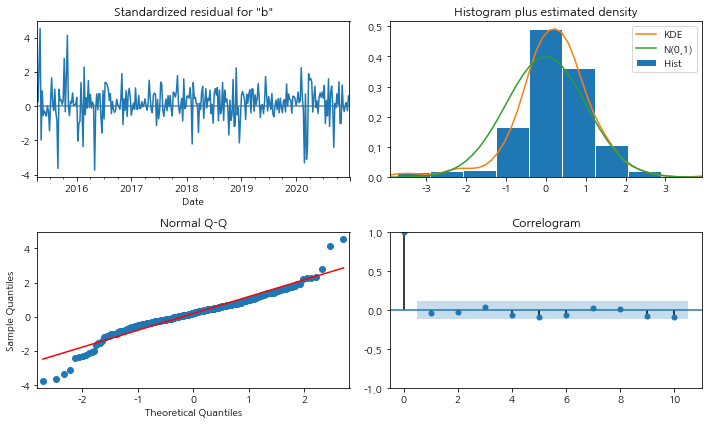

In [296]:
forecast = rs.get_forecast(steps=len(down_head))
f_mean = forecast.predicted_mean
MAE = mean_absolute_error(down_head[col], f_mean)
rmse = np.sqrt(mean_squared_error(down_head[col], f_mean))
print(f"MAE: {MAE:.3f}")
print(f"RMSE: {rmse:.3f}")
rs.plot_diagnostics(figsize=(10, 6)) #잔차 그래프
plt.tight_layout()
plt.show()

In [297]:
from pmdarima import auto_arima
auto_arima(down_head[col], start_p=1, start_q=1, max_p=5, max_q=5, start_P=0, start_Q=0, 
           max_P=5, max_Q=5, m=7, seasonal=False, trace=False, error_action='warn', suppress_warnings=True)

ARIMA(order=(0, 1, 1), scoring_args={}, suppress_warnings=True)

In [298]:
model2 = ARIMA(down_head[col], order=(0, 1, 1))
rs2 = model2.fit()
print(rs2.summary())

                               SARIMAX Results                                
Dep. Variable:                 boxcox   No. Observations:                  300
Model:                 ARIMA(0, 1, 1)   Log Likelihood                1075.734
Date:                Sun, 03 Aug 2025   AIC                          -2147.468
Time:                        00:52:07   BIC                          -2140.067
Sample:                    04-05-2015   HQIC                         -2144.506
                         - 12-27-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.1425      0.048      2.968      0.003       0.048       0.237
sigma2      4.385e-05   2.38e-06     18.411      0.000    3.92e-05    4.85e-05
Ljung-Box (L1) (Q):                   0.35   Jarque-

마찬가지로 등분산성, 정규성 불만족하나 likelihood, AIC 값이 더 좋으므로 이전모델 채택

4. 해당 모델로 down_tail의 기간 값을 예측하고, 적절한 평가지표를 선택하여 해당 모델을 평가하시오.

ARIMA(1, 1, 1) mse: 0.000
ARIMA(1, 1, 1) mape: 0.328

ARIMA(0, 1, 1) mse: 0.000
ARIMA(0, 1, 1) mape: 0.326



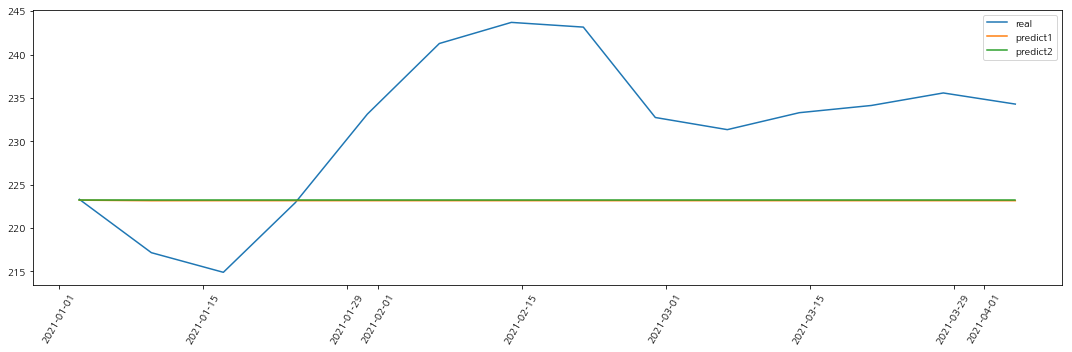

In [299]:
from sklearn.metrics import mean_squared_error

def MAPE(y_true, y_pred):
    mape = np.mean(np.abs((y_true - y_pred)/y_true))*100
    return mape

if 'boxcox' not in down_tail.columns:
    box = boxcox(down_tail['Close'], lmbda=lamb)
    down_tail['boxcox'] = box

pred1 = rs.predict(start=down_tail.index[0], end=down_tail.index[-1])
pred2 = rs2.predict(start=down_tail.index[0], end=down_tail.index[-1])

pr_list = [pred1, pred2]
title = ['ARIMA(1, 1, 1)', 'ARIMA(0, 1, 1)']

for p, t in zip(pr_list, title):
    mse = mean_squared_error(down_tail[col], p)
    mape = MAPE(down_tail[col].values, p.values)

    print(f"{t} mse: {mse:.3f}")
    print(f"{t} mape: {mape:.3f}\n")
    

from scipy.special import inv_boxcox

if 'boxcox' in col:
# y_boxcox: 변환된 값, lmbda: 변환할 때 사용한 람다
    pred1= inv_boxcox(pred1, lamb)
    pred2 = inv_boxcox(pred2, lamb)

fig, ax = plt.subplots(1, 1, figsize=(15, 5))

ax.plot(down_tail['Close'], label='real')
ax.plot(pred1, label='predict1')
ax.plot(pred2, label='predict2')
ax.tick_params(axis='x', labelrotation=60)
plt.legend()
plt.tight_layout()
plt.show()

두 번째 모델의 성능이 더 좋음  
해당 모델로 down_tail 데이터의 기간을 예측한 결과,   
MAPE 3.26%를 얻었다. 이는 실제값과 예측값이 평균적으로 3.26% 차이난다는 의미이다.